
# Nevergrad first call
Quick notebook to exercise the optimization step (Nevergrad) with the cached pipeline. Adjust overrides to control runtime and target.


In [1]:

# Ensure repo on sys.path (works when run from CLI or inside the notebook directory)
import sys
from pathlib import Path

# Start from CWD; if __file__ defined (exported), use that
repo_root = Path.cwd()
if '__file__' in globals():
    repo_root = Path(__file__).resolve().parents[2]

# Climb parents until we find the top-level nevermore/configs marker
marker = Path('nevermore/configs/default.yaml')
for parent in [repo_root] + list(repo_root.parents):
    if (parent / marker).exists():
        repo_root = parent
        break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('Repo root1:', repo_root)


Repo root1: /scratch/home/sr3622/Firm-DTI/Firm-DTI2


In [2]:

import json
import pandas as pd
from nevermore.pipeline import NevermorePipeline


STAGE_ORDER = [
    "ingest",
    "features",
    "optimization",
    "retrieval",
    "visualization",
    "docking",
    "report",
]

# Config and quick overrides
config_path = repo_root / 'nevermore' / 'configs' / 'default.yaml'
override_sample_index = None  # e.g., 10
override_target_sequence="MGLKAAQKTLFPLRSIDDVVRLFAAELGREEPDLVLLSLVLGFVEHFLAVNRVIPTNVPELTFQPSPAPDPPGGLTYFPVADLSIIAALYARFTAQIRGAVDLSLYPREGGVSSRELVKKVSDVIWNSLSRSYFKDRAHIQSLFSFITGTKLDSSGVAFAVVGACQALGLRDVHLALSEDHAWVVFGPNGEQTAEVTWHGKGNEDRRGQTVNAGVAERSWLYLKGSYMRCDRKMEVAFMVCAINPSIDLHTDSLELLQLQQKLLWLLYDLGHLERYPMALGNLADLEELEPTPGRPDPLTLYHKGIASAKTYYRDEHIYPYMYLAGYHCRNRNVREALQAWADTATVIQDYNYCREDEEIYKEFFEVANDVIPNLLKEAASLLEAGEERPGEQSQGTQSQGSALQDPECFAHLLRFYDGICKWEEGSPTPVLHVGWATFLVQSLGRFEGQVRQKVRIVSREAEAAEAEEPWGEEAREGRRRGPRRESKPEEPPPPKKPALDKGLGTGQGAVSGPPRKPPGTVAGTARGPEGGSTAQVPAPTASPPPEGPVLTFQSEKMKGMKELLVATKINSSAIKLQLTAQSQVQMKKQKVSTPSDYTLSFLKRQRKGL"
override_baseline_smiles ="CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2(C1)CCN(C[C@H]1CC[C@@H](CC1)NS(=O)(=O)CC)CC2"


pipe = NevermorePipeline(config_path=config_path)
if override_sample_index is not None:
    pipe.config.optimization.sample_index = override_sample_index
if override_target_sequence is not None:
    pipe.config.optimization.target_sequence = override_target_sequence
if override_baseline_smiles is not None:
    pipe.config.optimization.baseline_smiles = override_baseline_smiles

results = pipe.run(up_to='report', verbose=True)
opt_res = results.get('report')
print('Optimization signature:', opt_res.signature)
print('Outputs:', opt_res.outputs)
print('Details:', json.dumps(opt_res.details, indent=2))


SyntaxError: from __future__ imports must occur at the beginning of the file (steps.py, line 216)

In [3]:

# Inspect optimizsation summary CSV and target manifest
from pathlib import Path
summary_path = Path(opt_res.outputs.get('report', ''))
if summary_path.exists():
    display(pd.read_csv(summary_path).head(100))



,start_mol,dataset_index_x,smiles,smiles_length,mol_weight,distance_L1,max_bucket_difference,bucket_counts,predicted_affinity,dataset_index_y,molecular_weight,logP,HIA_Hou,hERG,QED,Lipinski
0,0,10,CCN(C(C)C)C(=O)C1=CC(F)=CC=C1OC1=CN=CN=C1N1CC2...,NaN,NaN,NaN,NaN,NaN,4.835561,NaN,630.831,4.67880,0.999101,0.945067,0.381630,3.0
1,1,0,COCc1ccccc1C1C(C(=O)C(C)C)C(=O)C(=O)N1c1ccc(cc...,56.0,447.556,35.400017,9.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, ...",2.472870,0.0,447.556,5.05980,0.999610,0.568593,0.375150,3.0
2,2,1,Cc1c2[C@@H]3CCCN([C@@H]3Cc2ccc1C#N)C(=O)c1ccc2...,56.0,356.429,33.200008,8.0,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ...",4.121687,1.0,356.429,3.68750,0.999980,0.934671,0.722638,4.0
3,3,2,CC(C)(C#N)c1cccc(C(=O)Nc2cccc(Oc3ccc4nc(NC(=O)...,68.0,556.047,36.000004,9.0,"[1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.690907,2.0,556.047,7.01566,0.998931,0.869036,0.252099,2.0
4,4,3,CC(=O)Nc1nc2ccc(Oc3cccc(NC(=O)Nc4ccc(cc4)C(C)(...,63.0,499.596,26.400003,10.0,"[1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.829741,3.0,499.596,6.86018,0.984773,0.857768,0.277307,3.0
5,5,4,Fc1ccc(Oc2ccc3nc(NC(=O)C4CC4)sc3c2C#N)cc1NC(=O...,66.0,555.513,35.800007,9.0,"[1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.831006,4.0,555.513,7.11068,0.997055,0.849454,0.219355,2.0
6,6,5,CC(=O)Nc1nc2ccc(Oc3cccc(NC(=O)Cc4cccc(c4)C(F)(...,63.0,510.497,35.600006,10.0,"[1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.648311,5.0,510.497,6.11868,0.997804,0.908874,0.325325,2.0
7,7,6,Fc1ccc(Oc2ccc3nc(NC(=O)C4CC4)sc3c2C#N)cc1NC(=O...,66.0,554.525,25.199997,9.0,"[1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.855060,6.0,554.525,6.64788,0.999307,0.866641,0.249139,2.0
8,8,7,FC(F)(F)Oc1ccc(cc1)N1CC[C@H]2CN(C[C@H]2C1=O)C(...,58.0,418.415,33.400005,8.0,"[0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",4.870756,7.0,418.415,3.63920,0.998499,0.820773,0.761975,4.0
9,9,8,Fc1ccc(cc1)C(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c...,64.0,422.378,33.800007,8.0,"[0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",5.883736,8.0,422.378,3.84940,0.996792,0.860787,0.706518,4.0


In [22]:
opt_res.outputs

{'report': PosixPath('/scratch/home/sr3622/Firm-DTI/Firm-DTI2/outputs/report/3423fc5d66a8/nevermore_report.csv')}

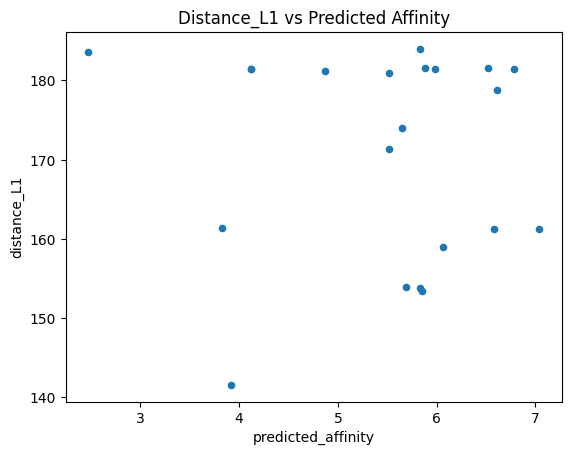

In [5]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

df = pd.read_csv(summary_path)

# Sort by distance_L1 (ascending) to inspect best matches first
df_sorted = df.sort_values("distance_L1", ascending=True)

ax = df_sorted.plot.scatter(x="predicted_affinity", y="distance_L1", title="Distance_L1 vs Predicted Affinity")
plt.show()





In [24]:
df_sorted

,start_mol,dataset_index_x,smiles,smiles_length,mol_weight,distance_L1,max_bucket_difference,bucket_counts,predicted_affinity,vina_score,dataset_index_y,molecular_weight,logP,HIA_Hou,hERG,QED,Lipinski
17,16,16,FC(F)(F)COc1ccc(cc1)N1CC[C@@H]2CN(C[C@@H]2C1=O...,66.0,489.903,72.599998,8.0,"[0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",6.585068,-7.1,16.0,489.903,3.34970,0.999594,0.770369,0.601753,4.0
2,2,1,Cc1c2[C@@H]3CCCN([C@@H]3Cc2ccc1C#N)C(=O)c1ccc2...,56.0,356.429,72.799988,8.0,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ...",4.121687,-6.9,1.0,356.429,3.68750,0.999980,0.934671,0.722638,4.0
3,2,1,Cc1c2[C@@H]3CCCN([C@@H]3Cc2ccc1C#N)C(=O)c1ccc2...,56.0,356.429,72.799988,8.0,"[0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, ...",4.121687,-7.9,1.0,356.429,3.68750,0.999980,0.934671,0.722638,4.0
15,14,14,FC(F)(F)Oc1ccc(cc1)N1CC[C@H]2CN(C[C@H]2C1=O)S(...,63.0,474.888,72.800011,8.0,"[0, 1, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",3.825368,-7.5,14.0,474.888,3.91220,0.999591,0.858000,0.673544,4.0
4,3,2,CC(C)(C#N)c1cccc(C(=O)Nc2cccc(Oc3ccc4nc(NC(=O)...,68.0,556.047,75.599998,9.0,"[1, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, ...",5.690907,-7.7,2.0,556.047,7.01566,0.998931,0.869036,0.252099,2.0
1,1,0,COCc1ccccc1C1C(C(=O)C(C)C)C(=O)C(=O)N1c1ccc(cc...,56.0,447.556,85.199982,9.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, ...",2.472870,NaN,0.0,447.556,5.05980,0.999610,0.568593,0.375150,3.0
11,10,9,CC(C)CC(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c1ccc(...,59.0,384.398,90.599998,8.0,"[0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",6.608219,-6.7,9.0,384.398,3.44260,0.999463,0.733141,0.799129,4.0
14,13,13,CC(C)CCS(=O)(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2C1)c...,64.0,434.480,90.800003,8.0,"[0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",6.066804,-7.4,13.0,434.480,3.24580,0.999040,0.832145,0.689534,4.0
13,12,12,CC(C)c1ccc(cc1)C(=O)N1C[C@@H]2CCN(C(=O)[C@@H]2...,68.0,446.469,92.799995,8.0,"[0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, ...",5.521128,-7.7,12.0,446.469,4.83370,0.998508,0.876917,0.675875,4.0
20,19,19,Cc1ccc(CC(=O)N2C[C@H]3CCN(C(=O)[C@H]3C2)c2ccc(...,64.0,446.469,92.999992,8.0,"[0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 2, 0, 0, 1, 0, ...",5.514193,-7.7,19.0,446.469,3.99012,0.999051,0.886282,0.698066,4.0


In [17]:
import pandas as pd
from pathlib import Path

# Point to your features run (replace with your signature if you know it)
feat_root = Path("../../outputs/features")
sig = "97df27707ad5"  # set to your features signature
admet_path = feat_root / sig / "admet_features.csv"

df = pd.read_csv(admet_path)

# Keep only numeric ADMET columns (drop metadata)
numeric_cols = [c for c in df.columns if c not in {"dataset_index", "smiles"}]
stats = df[numeric_cols].agg(["mean", "min", "max"]).T
stats.columns = ["mean", "min", "max"]

display(stats)


,mean,min,max
molecular_weight,454.732821,82.106000,4685.660000
logP,3.736960,-5.828600,48.547800
HIA_Hou,0.990563,0.007735,1.000000
hERG,0.758101,0.001559,0.997788
QED,0.510876,0.001937,0.947675
Lipinski,3.539405,0.000000,4.000000
